In [1]:
import numpy as np
from pynq import MMIO, PL, DefaultHierarchy, Overlay, allocate
from pynq.lib import LED
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
import time
from IPython.display import display, Image

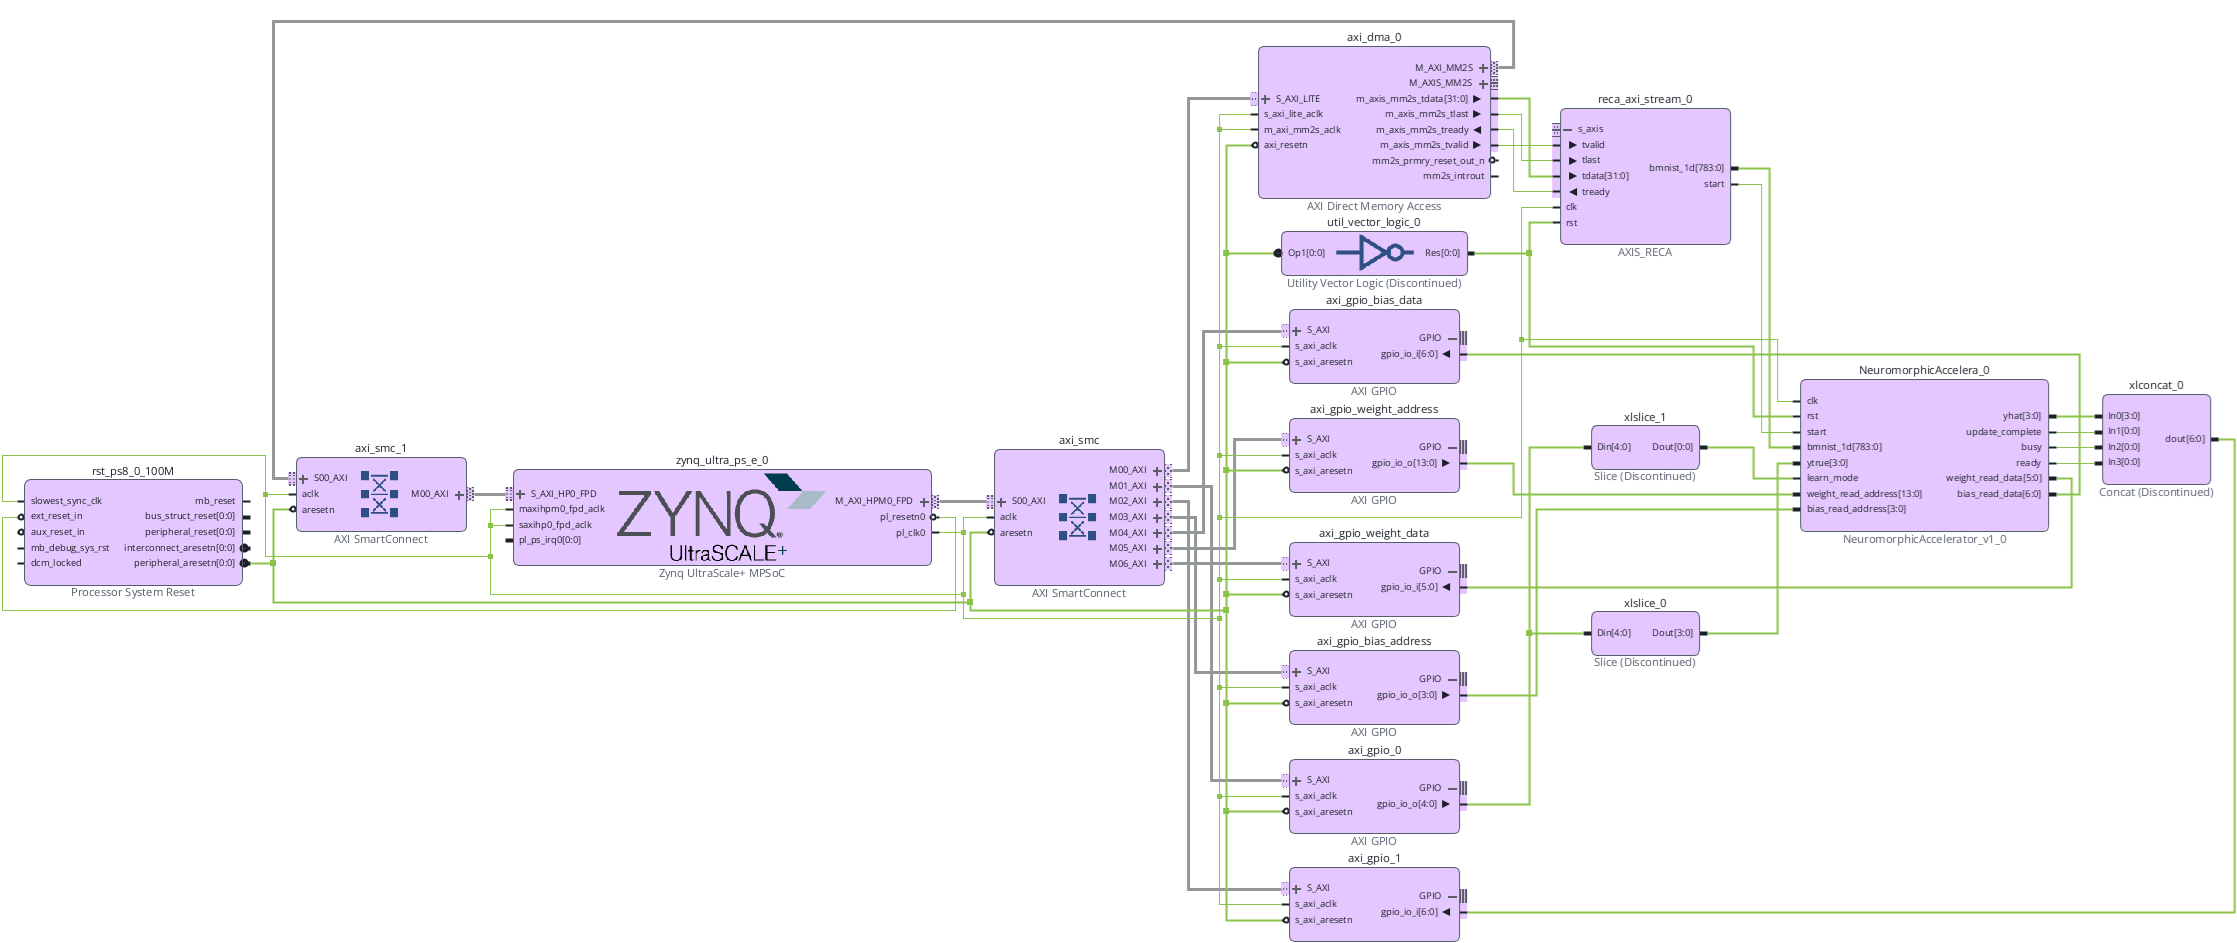

In [2]:
display(Image(filename="overview.png"))

### Loading MNIST images

In [3]:
X = np.load('/home/xilinx/jupyter_notebooks/x_mnist.npy', allow_pickle=False)
y = np.load('/home/xilinx/jupyter_notebooks/y_mnist.npy', allow_pickle=False)

### Transforming the grayscale images into binarized images

In [4]:
threshold = 90
X_binary = (X > threshold).astype(np.float32) 

### Before and after image preprocessing

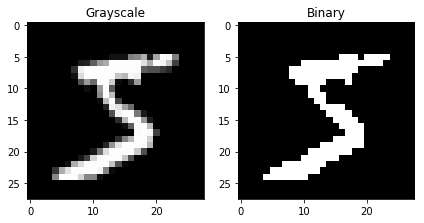

In [5]:
fig, axes = plt.subplots(1, 2)

axes[0].imshow(X[0].reshape(28, 28), cmap='gray')
axes[0].set_title("Grayscale")

axes[1].imshow(X_binary[0].reshape(28, 28), cmap='gray')
axes[1].set_title("Binary")

plt.tight_layout()
plt.show()


### Train, validation, test split (70%, 15%, 15%)

In [6]:
X_binary = np.array(X_binary)  

X_train, X_test, y_train, y_test = train_test_split(X_binary, y, test_size=0.15, stratify=y, random_state=16)
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=0.1765, stratify=y_train, random_state=16)

In [ ]:
print(f"#Images in X_train = {len(X_train)}")
print(f"#Images in X_validation = {len(X_validation)}")
print(f"#Images in X_test = {len(X_test)}")

### Training, validation and test functions

In [7]:
buffer = allocate(shape=(25,), dtype=np.uint32)  

def predict(img, ytrue, training):
    flattened = img.flatten().astype(np.uint8) # Flattening the binary MNIST 
    padded = np.zeros(800, dtype=np.uint8) # Padding until 25 words (784/32 = 24.5)
    padded[:784] = flattened # Slicing
    
    #words = np.array(np.packbits(padded[::-1]).view(np.uint32), dtype=np.uint32).copy()
    words = np.array(np.packbits(padded).view(np.uint32), dtype=np.uint32).copy()
    
    # Assigning label to the input, and if we want to learn from the prediction.
    # 5bit input, [4:0]:
    #  * [4]   = training (0-1)
    #  *[3:0] = input label   (0–9)
    # If training = 1 and ytrue = 3, then we are writing 00010011
    gpio_in.channel1.write((training << 4) | int(ytrue), 0x1F) # 0x1F is the write mask, meaning what bits we want to write on

    for j in range(25):
        buffer[j] = int(words[j])

    if not dma.sendchannel.running:
        dma.sendchannel.start()

    dma.sendchannel.transfer(buffer)

    # Waits to read the predicition, yhat, until the mode sends that its ready for a new input
    for _ in range(50000):
        status = gpio_out.channel1.read()
        if (status >> 6) & 1:
            break
        time.sleep(0.000001)
        
    yhat = gpio_out.channel1.read() & 0xF

    # Clears the input
    buffer.freebuffer()
    
    return yhat


def validate(X, y):
    correct = 0
    
    for i in range(len(X)):
        yhat = predict(X[i], y[i], training = 0)
        if yhat == y[i]:
            correct += 1
            
    return correct / len(X) * 100


def run_training(X_train, y_train, X_val, y_val, num_samples=len(X_train), validation=False):
    correct = 0
    validation_accuracy = []
    training_accuracy = []

    for i in range(num_samples):
        yhat = predict(X_train[i], y_train[i], training=1)
        if yhat == y_train[i]:
            correct += 1

        train_accuracy = correct / (i + 1) * 100

        if i == 0:
            if yhat == y_train[i]:
                status = "Correct"  
            else:
                status = "X"
            print(f"{i+1}/{num_samples} ytrue={y_train[i]} yhat={yhat} {status}")
            val_accuracy = validate(X_val, y_val)
            validation_accuracy.append((i + 1, val_accuracy))
            training_accuracy.append((i + 1, train_accuracy))

        if (i + 1) % 1000 == 0:
            if yhat == y_train[i]:
                status = "Correct"  
            else:
                status = "X"
            print(f"{i+1}/{num_samples} ytrue={y_train[i]} yhat={yhat} {status}")

            if validation:
                print(f"Validation at {i+1} training samples")
                val_accuracy = validate(X_val, y_val)
                print(f"Validation accuracy {val_accuracy:.2f}%\n")
                validation_accuracy.append((i + 1, val_accuracy))
                training_accuracy.append((i + 1, train_accuracy))

    return training_accuracy, validation_accuracy

### Training the final model

1/48998 ytrue=0 yhat=8 X
1000/48998 ytrue=3 yhat=3 Correct
Validation at 1000 training samples
Validation accuracy 63.97%

2000/48998 ytrue=1 yhat=1 Correct
Validation at 2000 training samples
Validation accuracy 72.73%

3000/48998 ytrue=3 yhat=5 X
Validation at 3000 training samples
Validation accuracy 64.16%

4000/48998 ytrue=4 yhat=8 X
Validation at 4000 training samples
Validation accuracy 79.36%

5000/48998 ytrue=3 yhat=3 Correct
Validation at 5000 training samples
Validation accuracy 83.12%

6000/48998 ytrue=9 yhat=4 X
Validation at 6000 training samples
Validation accuracy 66.92%

7000/48998 ytrue=8 yhat=5 X
Validation at 7000 training samples
Validation accuracy 74.73%

8000/48998 ytrue=1 yhat=1 Correct
Validation at 8000 training samples
Validation accuracy 83.04%

9000/48998 ytrue=3 yhat=3 Correct
Validation at 9000 training samples
Validation accuracy 78.34%

10000/48998 ytrue=9 yhat=9 Correct
Validation at 10000 training samples
Validation accuracy 76.31%

11000/48998 ytrue

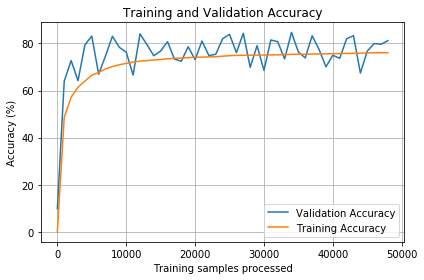

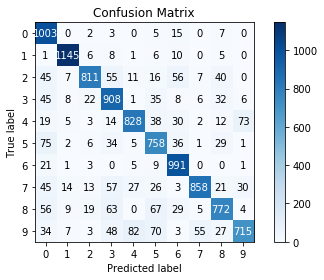

In [9]:
ol = Overlay('/home/xilinx/jupyter_notebooks/NeuromorphicAccelerator.bit') 

threshold = 90

X_binary = (X > threshold).astype(np.float32) 
X_binary = np.array(X_binary)  

X_train, X_test, y_train, y_test = train_test_split(X_binary, y, test_size=0.15, stratify=y, random_state=16)
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=0.1765, stratify=y_train, random_state=16)

dma = ol.axi_dma_0 
gpio_in = ol.axi_gpio_0  
gpio_out = ol.axi_gpio_1  
dma.sendchannel.start()

training, validation = run_training(X_train, y_train, X_validation, y_validation, validation = True)

test_acc = validate(X_test, y_test)
print(f"Test accuracy: {test_acc:.2f}%")

val_samples, val_accuracy = zip(*validation)
train_samples, train_accuracy = zip(*training)

plt.figure()
plt.plot(val_samples, val_accuracy, label="Validation Accuracy")
plt.plot(train_samples, train_accuracy, label="Training Accuracy")
plt.xlabel("Training samples processed")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

ytrue_list = []
yhat_list = []

for i in range(len(X_test)):
    yhat = predict(X_test[i], y_test[i], training=0)
    ytrue_list.append(y_test[i])
    yhat_list.append(yhat)
    

cm = confusion_matrix(ytrue_list, yhat_list)

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(10))
ax.set_yticklabels(range(10))
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix')

for i in range(10):
    for j in range(10):
        ax.text(j, i, str(cm[i][j]),
                ha='center', va='center',
                color='white' if cm[i][j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

### Saving parameters

In [ ]:

weight_addr_gpio = ol.axi_gpio_weight_address
weight_data_gpio = ol.axi_gpio_weight_data
bias_addr_gpio   = ol.axi_gpio_bias_address
bias_data_gpio   = ol.axi_gpio_bias_data

weights = np.zeros((10, 14*14*8), dtype=np.uint8) 
for c in range(10):
    for w in range(14*14*8):
        addr = c * (14*14*8) + w
        weight_addr_gpio.channel1.write(addr, 0x3FFF)
        time.sleep(0.001)
        weights[c][w] = weight_data_gpio.channel1.read()

biases = np.zeros(10, dtype=np.uint8)
for c in range(10):
    bias_addr_gpio.channel1.write(c, 0xF)
    time.sleep(0.001)
    biases[c] = bias_data_gpio.channel1.read()

with open("weights.mem", "w") as f:
    for c in range(10):
        for w in range(14*14*8):
            f.write(f"{weights[c][w]:02x}\n")

with open("biases.mem", "w") as f:
    for c in range(10):
        f.write(f"{biases[c]:02x}\n")
        
        
    